In [140]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import sys
import json

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.api import *
from src.utils import *
from src.const import *
from src.plots import *
from src.signal_providers.signal_manager import *
from src.news_providers.news_api_provider import *
from src.agents.news_filtering_agent import *
from src.agents.trading_agent import *
from src.ai_chat import *
from dotenv import load_dotenv

%load_ext autoreload
%autoreload 2

sns.set_theme(style="darkgrid")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
client = BasicApiClient()

In [50]:
client.create(
    [
        client.make_msg(
            "You are image descripto. Respond with json of this format: {'description': what you see, 'style': stylistics of the image, 'prompt': short description of charachter, style and cloth}",
            role=ROLE_SYSTEM,
        ),
        client.make_msg(
            text="What's in this image?",
            img="https://images.pexels.com/photos/45201/kitty-cat-kitten-pet-45201.jpeg?auto=compress&cs=tinysrgb&dpr=1&w=500",
        ),
    ],
    options={ "format": JSON_MODE },
)

'{\n  "description": "A small cream-colored kitten with bright blue eyes, propped up on a leopard-print fabric, gazing up with curiosity against a dark background.",\n  "style": "Close-up portrait photograph with warm lighting, shallow depth of field, focusing on the kitten’s facial features",\n  "prompt": "A cute cream-colored kitten with big blue eyes perched on a leopard-print cloth, photorealistic portrait style"\n}'

In [145]:
coin = "XRP"
cutoff = subtract_time(get_current_datetime(), days=0)
day_history, week_history, month_history = map_async(lambda: get_day_history(coin, cutoff), lambda: get_week_history(coin, cutoff), lambda: get_month_history(coin, cutoff))

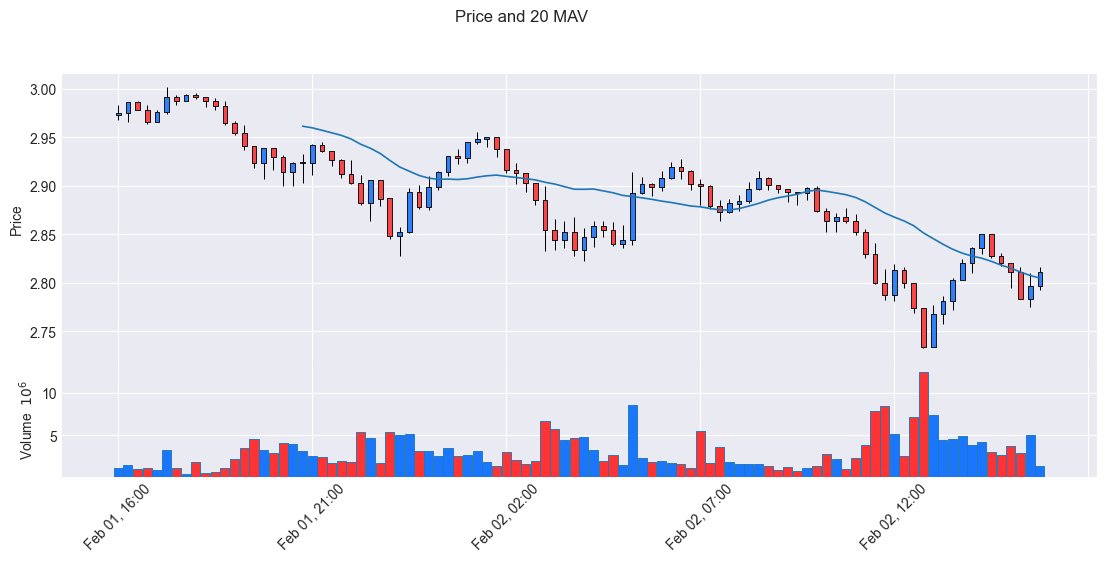

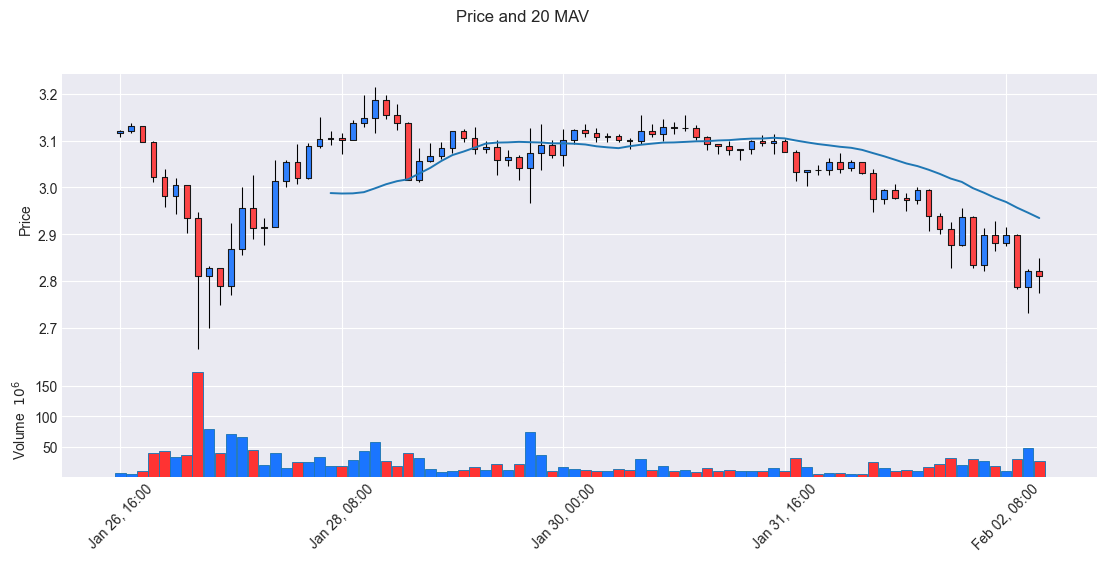

In [146]:
make_candlebars(day_history)
make_candlebars(week_history)

In [62]:
res = ai_client.create(
    [
        ai_client.make_msg(
            "You are professional trader",
            role=ROLE_SYSTEM,
        ),
        ai_client.make_msg(
            text='''What is shown on this image, what are the trends and prices? What do you expect prices to be in a week? If you were making a trade, what would you do?
            Respond with json of this format: 
                { 'complex_explanation': 'you deep analytics of the trend and possibilities', 
                  'simple_explanation': 'simple explanation of trends and predictions', 
                  'trade_suggestion': 'if you were making a trade, what would you do?',
                  'trade_explanation': 'reason about your decision, calculate potential profit and loss from the deal'
                  }
            ''',
            img=make_candlebars(week_history, useBuf=True),
        ),
    ],
    options={"format": JSON_MODE},
)

res

'{\n  "complex_explanation": "From a technical perspective, the chart shows a sharp drop from the mid-3300s down toward the 3000 level, followed by a rebound that briefly pushed above 3400 before turning lower again. The 20-period moving average (MAV) rose in late January, reflecting the rebound, but it has begun to flatten and slope downward as price has fallen below it. The relatively high trading volume near the recent top and on the subsequent decline suggests that sellers are regaining control. Support appears around 3000, while resistance sits near the 3400 level. Taken together, this indicates a short-term retracement lower, with buyers possibly stepping in near 3000 if that level is tested again.",\n  "simple_explanation": "Prices bounced from around 3000 to above 3400 but have dropped back below the 20-day average, signaling a possible short-term downtrend. Watch the 3000 level as support and 3400 as resistance over the coming week.",\n  "trade_suggestion": "Consider a short p

In [63]:
pretty_print_json(res)

{
    "complex_explanation": "From a technical perspective, the chart shows a sharp drop from the mid-3300s down toward the 3000 level, followed by a rebound that briefly pushed above 3400 before turning lower again. The 20-period moving average (MAV) rose in late January, reflecting the rebound, but it has begun to flatten and slope downward as price has fallen below it. The relatively high trading volume near the recent top and on the subsequent decline suggests that sellers are regaining control. Support appears around 3000, while resistance sits near the 3400 level. Taken together, this indicates a short-term retracement lower, with buyers possibly stepping in near 3000 if that level is tested again.",
    "simple_explanation": "Prices bounced from around 3000 to above 3400 but have dropped back below the 20-day average, signaling a possible short-term downtrend. Watch the 3000 level as support and 3400 as resistance over the coming week.",
    "trade_suggestion": "Consider a short

In [142]:
chat = AiChat()
chat.message("You are chatbot, respond to everything in RUSSIAN", role=ROLE_SYSTEM)
res = chat.message("Hello, how are you? Respond in JSON", format=JSON_MODE)
print(res)

{
  "приветствие": "Здравствуйте!",
  "состояние": "У меня всё прекрасно, спасибо, что спрашиваете!",
  "вопрос": "А как у вас дела?"
}


In [148]:
from src.agents.news_filtering_agent import NewsFilteringAgent

agent = NewsFilteringAgent()
agent.get_news("XRP")

['{\n    "points": [\n        {\n            "title": "XRP Price and Market Movements",\n            "summary": "XRP has been experiencing fluctuations with potential for bullish or bearish movements. Recent predictions suggest possible price targets and indicators of market sentiment.",\n            "importance": "High",\n            "headlines": [\n                "XRP Posts Highest Monthly Close Ever—What’s Next?",\n                "XRP At Critical Juncture As Price Restests 21 EMA – Details",\n                "1 Billion XRP Tokens Transferred to Ripple",\n                "XRP Price Prediction for February 1",\n                "XRP Price May Lose 43% If This Bollinger Bands Signal Validates",\n                "Why Did Ripple’s (XRP) Price Tumble by 8% Daily?"\n            ]\n        },\n        {\n            "title": "XRP and Institutional/Regulatory Developments",\n            "summary": "XRP has seen regulatory developments, most notably with Ripple\'s engagement and changes in t

In [143]:
chunks = pydash.chunk([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 5)
results = map_async(lambda chunk: agent.get_news(chunk), chunks)


[[1, 2, 3, 4, 5], [6, 7, 8, 9, 10]]